# San Francisco movie scene

This notebook presents the journey we took to build the [San Francisco Film website](https://www.omdbapi.com/)

---

### Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | [Motivation](#Motivation) | Data description and UX goal |
| 2 | [Basic Stats](#Basic-Stats) | Data preprocessing and exploratory data analysis |
| 3 | [Data Analysis](#Data-Analysis) | Data processing, data analysis and sentiment analysis used |
| 4 | [Genre](#Genre) | Smth here |
| 5 | [Visualization](#Visualization) | Smth here |
| 6 | [Discussion](#Discussion) | Smth here |
| 7 | [Contributions](#Contributions) | Team contributions |
| 8 | [Use of AI](#Use-of-AI) | How AI was used |
| 9 | [References](#References) | List of references used |
| 10 | [Appendix](#Appendix) | Additional graphs and code for further details |

## Motivation

As people who like movies and data, we decided to explore the San Francisco filming history to see if there were patterns or information that could tell us what makes a movie succesful. There are a lot of factors that can influence a movie into becoming a hit, so we decided to explore some of them and guide users through our journey, giving them the insights we got at the same time they have the opportunity to explore by themselves.

---

### What is your dataset?

We built our own dataset by combining two sources:
- The Film Location database of the open data portal of San Francisco ([Open SF](https://data.sfgov.org/Culture-and-Recreation/Film-Locations-in-San-Francisco/yitu-d5am/about_data))<sup><a href="#ref1">[1]</a></sup>, which contains basic information about the films that have been filmed in San Francisco, as well as geographical data to know where they were filmed.
- [OMDb API](https://www.omdbapi.com/)<sup><a href="#ref2">[2]</a></sup> for obtaining more of the films information. It is a free alternative to get the information presented in the IMDb website.

---

### Why did you choose this/these particular dataset(s)?

Our base dataset was the Film Location database of San Francisco, which was chosen due to the geographical dimension it adds to the movie information. Movie datasets tend to have limited information regarding the locations at which their filming took place, but this dataset has a bigger granularity, allowing to see the neighborhoods, places and coordinates of the filmings.

That dataset had a good detail in geographical terms, but was limited in terms of information presented about the movie. Therefore, we decided to complement it with IMDb information, allowing us to make a more complete analysis. However, it costs money to access the IMDb complete database, so we took an alternative through the OMDb API, which allowed us to fetch many of the same IMDb data by free.

---

### What was your goal for the end user's experience?

Our goal is to allow users to learn and explore about films in two not so common dimensions: geographical and emotional. We want them to realize how a different take into films data can reveal valuable information regarding succesful movies. 

As these topics can be complex for users that are not familiar to data analysis, we created a dynamic website which guides the users through it, allowing them to learn and comprehend the information without having to learn a lot of text.

---

## Basic Stats

### Write about your choices in data cleaning and preprocessing

The original San Francisco dataset contains 2214 rows and 18 columns. Each row contains information of a filming location, so a single title could have more than one related row of information. Considering this, we decided to extract the unique titles and release year (in case two different movies had the same name), manually search all of them and mark them in case they had a different name in IMDb (OMDb). To simplify this process, we did it on a separate file. The way we marked them was by adding a new IMDb ID column to the separated file. If they were not found they were flagged to delete. 16 rows (7 Unique Titles) were deleted following that rule.

As the OMDb API retrieval needs to match either the exact title or the IMDb ID, we used both columns of the dataset to retrieve the information. We merged the separated file with the San Francisco filming dataset, and from there, we performed the information retrieval. 156 unique titles were searched by using the IMDb ID (1224 rows), while 189 unique titles were searched by using the title (1020 rows). For the OMDb API information retrieval, we decided to fetch the following information:

| Field | API Key | Category |
|-------|---------|----------|
| `imdb_id` | `imdbID` | Identity |
| `title` | `Title` | Identity |
| `year` | `Year` | Identity |
| `kind` | `Type` | Identity |
| `genres` | `Genre` | Content |
| `plot` | `Plot` | Content |
| `language` | `Language` | Content |
| `country` | `Country` | Content |
| `certificates` | `Rated` | Content |
| `runtime` | `Runtime` | Content |
| `awards` | `Awards` | Content |
| `directors` | `Director` | People |
| `writers` | `Writer` | People |
| `imdb_rating` | `imdbRating` | Ratings |
| `imdb_votes` | `imdbVotes` | Ratings |
| `metascore` | `Metascore` | Ratings |
| `ratings` | `Ratings` | Ratings |
| `box_office` | `BoxOffice` | Commercial |
| `poster` | `Poster` | Media |

Once we had that information, we merged it with the San Francisco dataset and cleaned it. Some of the columns were repeated information so we dropped them. At the end we finished with a dataset with 2244 rows and 30 columns (the entire process can be seen in [Appendix](#Appendix)).

### Dataset stats and key points/plots from your exploratory data analysis.

The final dataset contains films from 1915 up to 2025. It enlists 24 unique genres with 40 neighborhoods appearing. Out of the 316 unique titles, 291 of them are movies, while 25 are series. Of the total movies, the 291 of them have a plot description, 202 of them contain information about their domestic box office, 286 have IMDb rating, and 243 have some kind of awards. Within the awards section, only 24 are Oscar winners.

Our first approach to the dataset was related to geographical and time data. Therefore, we started by listing the most filmed neighborhoods, making a map with the location of filmings according to their genre, plotting the number of films per decade, and, after seeing some patterns, we decided to combine geography and time with specific "success" concepts such as box office.

<table>
  <tr>
    <td align="center"><img src="images/most_film_neigh.png" width="600" height="330"/><br/>Bar chart - Most filmed neighborhoods</td>
    <td align="center"><img src="images/geog_genres.png" width="600" height="330"/><br/>Folium map - Filming locations by genre</td>
  </tr>
  <tr>
    <td align="center"><img src="images/SF_time_films.png" width="600" height="330"/><br/>Bar chart - Number of films per decade</td>
    <td align="center"><img src="images/box_office_heatmap.png" width="600" height="330"/><br/>Heatmap - Box office by neighborhood and decade</td>
  </tr>
</table>

The shown graphs code can be found in [Appendix](#Appendix). By exploring this information and relations, we were able to find some patterns, which led us to the data analysis we performed, and also to the addition of a different dimension, which was the emotions (sentiment analysis).

## Data Analysis

### Data analysis and learnings

The data analysis we performed was divided in 2 paths. The first path was focused on the geographical data, and used the dataset we created with the addition of a [geoJSON file](https://data.sfgov.org/-/SF-Find-Neighborhoods/pty2-tcw4)<sup><a href="#ref3">[3]</a></sup> of San Francisco Neighborhoods. The second path was focused on the sentiment analysis and used the dataset we created with the addition of VADER, a sentiment analysis tool.

#### Geographical data path

There were two different approaches we took for the geographic data. One based on the precise coordinates (latitude and longitude) and another based on neighborhood boundaries. In both approaches the folium library was used and rows missing coordinate data were removed. For the time-based visualizations, a new Decade column was added by using the "Year" information the dataset has. In the case of the second approach (neighborhood), it required some extra processing. A geoJSON file was used, containing polygon boundaries of all San Francisco neighborhoods. Each filming location in the dataset was evaluated to determine which neighborhood it fell into, and a count of locations per neighborhood was built from there. The basic code on which the visualizations was based on can be found in [SF on Screen — Opening Scrollytelling Map](#sf-on-screen--opening-scrollytelling-map).

<table>
  <tr>
    <td align="center"><img src="images/geo_heatmap.png" width="600" height="330"/><br/>Folium heatmap - use of coordinates to show information</td>
    <td align="center"><img src="images/geojson_map.png" width="600" height="330"/><br/>Folium map - GeoJson use for neighborhood boundaries</td>
  </tr>
</table>

Through the geographical data, we were able to find patterns in relation to the "success" of movies. We were able to see that filmings, box office hits, Oscar winners and highly rated IMDb films tend to concentrate in the north-east part of San Francisco. The data also revealed outliers, and how the different definitions of success shift across the city.

#### Sentiment analysis path



smth smth

## Genre

Our website follows a **Martini Glass** narrative structure (Segel & Heer, 2010). The reader is first guided through a linear, author-driven journey - from the geographical history of San Francisco cinema, through neighbourhood-level patterns of success and into an emotional analysis of film plots - before arriving at a fully interactive map to explore the data freely. This structure suits our story well: we have a clear argumentative thread we want the reader to follow, but the final interactive section respects their autonomy to ask their own questions of the data.

### Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why?

The initial map with the movies in time uses a consistent visual platform with a timebar. We use continuity editing to show the shift in density.

The maps section starts with an establishing shot, using continuity editing to create a seamless flow from density to focal points. We use a consistent visual platform ending with only certain features being highlighted (feature distinction).

The movie emotional range visualisation uses animated transitions and feature distinction to highlight various movies.

The genre plot uses a short animated transition in the beginning.

The movie scores uses feature distinction to highlight negative/positive scores. Through an animated transition this changes from dots to a histogram.

The next histograms use object continuity (keeping the histogram style across visualisations). They highlight different success metrics, thus using feature distinction. They use short animations when scrolling.

The final visualisation uses the familiar object (the same SF map that has been shown across the website). The user can zoom, move through the map (motion), have a close-up of the movie information.


### Which tools did you use from each of the 3 categories of Narrative Structure (Figure 7 in Segal and Heer). Why?

We wanted to use the Martini Glass Structure for our website, starting with visualizations that require little to no interaction from the user (besides scrolling) and ending with a fully interactive visualization where the user can explore the data on his own.

The ordering is linear. For interactivity, we use in the final map hover highlighting, filtering and selection. As for the messaging, we used headlines, annotations, multi-messaging (same map, different metrics), comment repetition (inside the text through the maps presentation we reference the two density peaks mentioned in a text box above), introductory text and a summary.

## Visualizations

The website tells its story through five visualization groups, progressing from spatial data to emotional data. 

Each group is described below with two layers: 
* **Analysis** - the code that produced the insight
* **Presentation** - why we chose this particular visual form to communicate it.

### SF on Screen — Opening Scrollytelling Map

The website opens with a map of San Francisco that plays like a film. As readers scroll, the visualization moves through each decade, from the 1910s to the 2020s. This shows the city's filming history. After the time sweep, the map shifts to a neighborhood view. Then, the focus changes from when to where films were concentrated.

#### Analysis

In [ ]:
# Main imports for Opening Scrollytellyng Maps
import folium
from folium.plugins import HeatMapWithTime
import pandas as pd
import json
from shapely.geometry import Point, shape

# Load the data
df_map = pd.read_csv("sf_movies_cleaned.csv")

In [10]:
# Data preparation for the decade-based heatmap animation
df_heat = df_map.dropna(subset=["Latitude", "Longitude", "Year"]).copy()
df_heat["Year"] = df_heat["Year"].astype(int)
# Create a decade column for grouping
df_heat["Decade"] = (df_heat["Year"] // 10 * 10)

decades = sorted(df_heat["Decade"].unique())

heat_data_by_decade = []
time_labels = []

# Cumulative heatmap per decade
for decade in decades:
    cumulative = df_heat[df_heat["Decade"] <= decade]
    heat_data_by_decade.append(
        cumulative[["Latitude", "Longitude"]].values.tolist()
    )
    time_labels.append(f"{decade}s")

# Create the map

ani_map = folium.Map(
    location=[37.7749, -122.4194],
    zoom_start=12,
    tiles="CartoDB dark_matter",
)

HeatMapWithTime(
    heat_data_by_decade,
    index=time_labels,
    radius=20,
    blur=0.85,
    min_opacity=0.05,
    max_opacity=0.75,
    scale_radius=False,
    use_local_extrema=False,
    auto_play=True,
    display_index=True,
    index_steps=1,
    min_speed=0.1,
    max_speed=4,
    speed_step=0.5,
    position="bottomleft",
    gradient={
        "0.0": "#0d1b2a",   # near-black — lowest density, almost invisible
        "0.2": "#1a3a5c",   # deep navy
        "0.45": "#1d6a8a",  # teal-blue mid
        "0.65": "#c47a2b",  # warm amber — hotspots start to glow
        "0.85": "#b84c2b",  # burnt coral
        "1.0": "#e8d5b0",   # warm off-white — only the absolute peaks
    },
).add_to(ani_map)


# ani_map.save("sf_map_heatmap_animated.html")
# print("Saved sf_map_heatmap_animated.html")
ani_map

In [ ]:
# Data preparation for neighborhood-based heatmap

# Load San Francisco neighborhood GeoJSON and clean it
with open("SF_Find_Neighborhoods_20260428.geojson", "r") as f:
    raw_geojson = json.load(f)

# Clean the GeoJSON properties (remove keys starting with ":")
NAME_FIELD = "name"

clean_features = []
for feature in raw_geojson["features"]:
    clean_props = {
        k: v for k, v in feature["properties"].items()
        if not k.startswith(":")
    }
    clean_features.append({
        "type":       "Feature",
        "geometry":   feature["geometry"],
        "properties": clean_props,
    })

neighborhoods_geojson = {
    "type":     "FeatureCollection",
    "features": clean_features,
}

# Build shapely geometries
geo_shapes = []
for feature in neighborhoods_geojson["features"]:
    geo_shapes.append({
        "name":     feature["properties"][NAME_FIELD].strip(),
        "geometry": shape(feature["geometry"]),
    })

# Assign neighborhood names to each filming location based on lat/lng (values inside neighborhood polygons, or closest)
def find_neighborhood(lat, lng):
    pt = Point(lng, lat)
    for gs in geo_shapes:
        if gs["geometry"].contains(pt):
            return gs["name"]
    min_dist, nearest = float("inf"), None
    for gs in geo_shapes:
        dist = gs["geometry"].centroid.distance(pt)
        if dist < min_dist:
            min_dist = dist
            nearest  = gs["name"]
    return nearest

df_clean = df_map.dropna(subset=["Latitude", "Longitude"]).copy()
df_clean["geo_neighborhood"] = df_clean.apply(
    lambda row: find_neighborhood(row["Latitude"], row["Longitude"]),
    axis=1
)

# Count the number of filming locations per neighborhood
count_map = df_clean["geo_neighborhood"].value_counts().to_dict()
max_count = max(count_map.values()) if count_map else 1

# Print summary stats
print(f"Neighborhoods found:   {len(count_map)}")
print(f"Total locations mapped: {sum(count_map.values()):,}")
print(f"\nTop 10 neighborhoods by filming locations:")
print(pd.Series(count_map).sort_values(ascending=False).head(10).to_string())

# Add film count to GeoJSON properties
for feature in neighborhoods_geojson["features"]:
    name = feature["properties"][NAME_FIELD].strip()
    feature["properties"]["film_count"] = int(count_map.get(name, 0))

# Create map
map_neigh = folium.Map(
    location=[37.7749, -122.4194],
    zoom_start=12,
    tiles="CartoDB dark_matter",
)

# Add neighborhoods as layer with color instensity
folium.GeoJson(
    neighborhoods_geojson,
    name="Neighborhoods",
    style_function=lambda feature: {
        "fillColor":   "steelblue",
        "fillOpacity": 0.1 + 0.7 * (feature["properties"]["film_count"] / max_count),
        "color":       "white",
        "weight":      0.5,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[NAME_FIELD, "film_count"],
        aliases=["Neighborhood", "Films recorded"],
    ),
).add_to(map_neigh)

map_neigh

Neighborhoods found:   102
Total locations mapped: 2,156

Top 10 neighborhoods by filming locations:
Financial District         146
North Beach                142
South of Market            132
Nob Hill                   131
Chinatown                  113
Mission                    105
Russian Hill                90
Civic Center                72
Potrero Hill                67
Downtown / Union Square     64


#### Presentation on the website

We chose a scrollytelling full-screen map as the opening because it immediately answers the first question a reader asks: *what is this dataset?* A static map of all filming locations at once would be a visual blob; animating through time turns the same data into a story — the city slowly lights up, and the reader watches a century of cinema unfold. The time-to-space transition (decade sweep → neighbourhood heat) was a deliberate pacing choice: it lets the reader build spatial intuition before we start asking them to compare areas.

The dark tile layer and slow crossfade between decades were chosen for cinematic feel, consistent with the film-focused subject matter.


### City Through the Lens — Map Scrollytelling

After the opening sequence, the story shifts to four Folium heat maps presented as scroll steps, followed by four neighbourhood highlight markers. Each heat map weights San Francisco filming locations by a different metric, letting the reader 'see the city' through four lenses:

1. **Filming density** - raw concentration of filming locations (blue → red heat)
2. **Box office performance** - locations weighted by film revenue
3. **IMDb rating** - locations weighted by audience score
4. **Oscar recognition** - markers for filming locations tied to Oscar-winning films

Four neighbourhood close-ups then drill into specific findings: Financial District (most filmed), Lone Mountain (highest box office), Lincoln Park (highest IMDb), and Haight Ashbury (the outlier — high revenue, low rating).


#### Analysis


In [37]:
# Core imports
from pathlib import Path

import numpy as np
import pandas as pd
import folium
from folium.plugins import HeatMap

# Output folder for generated HTML maps
OUTPUT_DIR = Path("maps_output")
OUTPUT_DIR.mkdir(exist_ok=True)

In [38]:
# Load data
DATA_PATH = Path("sf_movies_cleaned.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Could not find sf_movies_cleaned.csv. Place it in the same folder as this notebook "
        "or update DATA_PATH to the correct location."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows and {len(df.columns):,} columns.")
df.head()

FileNotFoundError: Could not find sf_movies_cleaned.csv. Place it in the same folder as this notebook or update DATA_PATH to the correct location.

In [ ]:
# Keep one row per film title so repeated filming locations do not over-count a movie.
# This is the only preparation step needed by the map cells below.
df_unique = df.drop_duplicates(subset=["Title"]).reset_index(drop=True)

print(f"Original rows: {len(df):,}")
print(f"Unique film/show titles: {len(df_unique):,}")

Original rows: 2,244
Unique film/show titles: 316


In [ ]:
# Shared map settings and helper functions
SF_CENTER = [37.7749, -122.4194]
DARK_TILES = "CartoDB dark_matter"
HEAT_GRADIENT = {
    0.2: "#0000ff",
    0.4: "#00ffff",
    0.6: "#ffff00",
    0.8: "#ff7700",
    1.0: "#ff0000",
}


def make_base_map(zoom_start=12):
    """Create a consistent San Francisco base map."""
    return folium.Map(location=SF_CENTER, zoom_start=zoom_start, tiles=DARK_TILES)


def save_map(map_object, filename):
    """Save a Folium map to maps_output/ and return the path."""
    output_path = OUTPUT_DIR / filename
    map_object.save(output_path)
    print(f"✅ Saved: {output_path}")
    return output_path


def add_highlight_marker(map_object, coords, label, radius=15):
    """Add the gold neighborhood marker used in the story maps."""
    folium.CircleMarker(
        location=coords,
        radius=radius,
        popup=label,
        color="white",
        fill=True,
        fillColor="gold",
        fillOpacity=0.7,
        weight=3,
    ).add_to(map_object)
    return map_object

#### Filming location density map

This map shows where San Francisco filming locations are concentrated.

In [ ]:
# Prepare location data
location_data = df_unique[["Latitude", "Longitude"]].dropna()
heat_coords = location_data[["Latitude", "Longitude"]].values.tolist()

print(f"Locations for heat map: {len(location_data):,}")
print(f"Latitude range: {location_data['Latitude'].min():.4f} to {location_data['Latitude'].max():.4f}")
print(f"Longitude range: {location_data['Longitude'].min():.4f} to {location_data['Longitude'].max():.4f}")

# Create map
filming_density_map = make_base_map()
HeatMap(
    heat_coords,
    radius=25,
    blur=15,
    max_zoom=1,
    gradient=HEAT_GRADIENT,
    min_opacity=0.3,
).add_to(filming_density_map)

save_map(filming_density_map, "filming_density_heatmap.html")
filming_density_map

Locations for heat map: 259
Latitude range: 37.7074 to 37.8452
Longitude range: -122.5301 to -122.3649
✅ Saved: maps_output/filming_density_heatmap.html


#### Box office heat map

This map weights filming locations by box office revenue. Warmer areas indicate locations associated with higher box office values.

In [ ]:
# Prepare box office data
boxoffice_data = df_unique.dropna(subset=["Box_office", "Latitude", "Longitude"]).copy()

# Clean box office values such as "$123,456" into numbers
boxoffice_data["Box_office_clean"] = (
    boxoffice_data["Box_office"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
boxoffice_data["Box_office_numeric"] = pd.to_numeric(boxoffice_data["Box_office_clean"], errors="coerce")
boxoffice_data = boxoffice_data.dropna(subset=["Box_office_numeric"])

bo_min = boxoffice_data["Box_office_numeric"].min()
bo_max = boxoffice_data["Box_office_numeric"].max()

if bo_max == bo_min:
    boxoffice_data["bo_normalized"] = 1.0
else:
    boxoffice_data["bo_normalized"] = (
        (boxoffice_data["Box_office_numeric"] - bo_min) / (bo_max - bo_min)
    )

heat_data_boxoffice = boxoffice_data[["Latitude", "Longitude", "bo_normalized"]].values.tolist()

print(f"Box office data points: {len(boxoffice_data):,}")
print(f"Box office range: ${bo_min:,.0f} to ${bo_max:,.0f}")

# Create map
box_office_map = make_base_map()
HeatMap(
    heat_data_boxoffice,
    radius=25,
    blur=15,
    max_zoom=1,
    gradient=HEAT_GRADIENT,
    min_opacity=0.3,
).add_to(box_office_map)

save_map(box_office_map, "box_office_heatmap.html")
box_office_map

Box office data points: 163
Box office range: $1,802 to $330,455,270
✅ Saved: maps_output/box_office_heatmap.html


#### IMDb rating heat map

This map weights filming locations by IMDb rating. Warmer areas indicate locations associated with higher rated films.

In [ ]:
# Prepare IMDb data
imdb_data = df_unique.dropna(subset=["Imdb_rating", "Latitude", "Longitude"]).copy()
imdb_data["Imdb_rating_numeric"] = pd.to_numeric(imdb_data["Imdb_rating"], errors="coerce")
imdb_data = imdb_data.dropna(subset=["Imdb_rating_numeric"])

# IMDb ratings are on a 0–10 scale, so divide by 10 for HeatMap intensity.
imdb_data["imdb_normalized"] = imdb_data["Imdb_rating_numeric"] / 10
heat_data_imdb = imdb_data[["Latitude", "Longitude", "imdb_normalized"]].values.tolist()

print(f"IMDb rating data points: {len(imdb_data):,}")
print(
    f"IMDb rating range: {imdb_data['Imdb_rating_numeric'].min():.1f} "
    f"to {imdb_data['Imdb_rating_numeric'].max():.1f}"
)

# Create map
imdb_rating_map = make_base_map()
HeatMap(
    heat_data_imdb,
    radius=25,
    blur=15,
    max_zoom=1,
    gradient=HEAT_GRADIENT,
    min_opacity=0.3,
).add_to(imdb_rating_map)

save_map(imdb_rating_map, "imdb_rating_heatmap.html")
imdb_rating_map

IMDb rating data points: 254
IMDb rating range: 3.8 to 8.8
✅ Saved: maps_output/imdb_rating_heatmap.html


#### Oscar recognition map

This map marks filming locations connected to films whose awards text includes “Oscar”.

In [ ]:
# Prepare Oscar data
oscar_data = df_unique.dropna(subset=["Latitude", "Longitude"]).copy()
oscar_data["won_oscar"] = (
    oscar_data["Awards"]
    .fillna("")
    .astype(str)
    .str.contains("Oscar", case=False, regex=False)
)
oscar_winners = oscar_data[oscar_data["won_oscar"]].copy()

print(f"Total films with location data: {len(oscar_data):,}")
print(f"Oscar-winning films with coordinates: {len(oscar_winners):,}")

# Create map
oscar_winners_map = make_base_map()
for _, row in oscar_winners.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=6,
        popup=row.get("Title", "Oscar Winner"),
        color="white",
        fill=True,
        fillColor="gold",
        fillOpacity=0.7,
        weight=2,
    ).add_to(oscar_winners_map)

save_map(oscar_winners_map, "oscar_winners_map.html")
oscar_winners_map

Total films with location data: 259
Oscar-winning films with coordinates: 57
✅ Saved: maps_output/oscar_winners_map.html


#### Analysis behind the key neighborhood highlight maps

Before creating the single marker highlight maps, this section calculates why each neighborhood was selected:

- **Financial District/South Beach**: selected because it has the highest number of unique films / filming activity.
- **Lone Mountain/USF**: selected because it has the strongest score for box office performance.
- **Lincoln Park**: selected because it has the highest average IMDb rating.
- **Haight Ashbury**: selected because it shows a useful contrast: high box office performance but relatively low IMDb rating.


In [ ]:
# Analysis for choosing the highlighted neighborhoods
# This cell recreates the neighborhood-level success metrics used to justify the story maps.

NEIGHBORHOOD_COL = "Analysis neighborhood"

# 1) Filming activity: count unique titles per neighborhood
neighborhood_activity = (
    df_unique
    .dropna(subset=[NEIGHBORHOOD_COL])
    .groupby(NEIGHBORHOOD_COL)
    .agg(
        Film_Count=("Title", "nunique"),
        Avg_Latitude=("Latitude", "mean"),
        Avg_Longitude=("Longitude", "mean"),
    )
    .sort_values("Film_Count", ascending=False)
)

print("MOST FILMED NEIGHBORHOODS")
print("=" * 70)
display(neighborhood_activity.head(10))

# 2) Box office success: clean Box_office and calculate average revenue per neighborhood
boxoffice_by_neighborhood = boxoffice_data.groupby(NEIGHBORHOOD_COL).agg(
    Box_Office_Count=("Title", "nunique"),
    Avg_Box_Office=("Box_office_numeric", "mean"),
    Median_Box_Office=("Box_office_numeric", "median"),
    Total_Box_Office=("Box_office_numeric", "sum"),
).round(0)

boxoffice_by_neighborhood = boxoffice_by_neighborhood.sort_values("Avg_Box_Office", ascending=False)

print("\nBOX OFFICE SUCCESS BY NEIGHBORHOOD")
print("=" * 70)
display(boxoffice_by_neighborhood.head(10))

# 3) IMDb success: calculate average rating per neighborhood
imdb_by_neighborhood = imdb_data.groupby(NEIGHBORHOOD_COL).agg(
    IMDB_Count=("Title", "nunique"),
    Avg_IMDB_Rating=("Imdb_rating_numeric", "mean"),
    Median_IMDB_Rating=("Imdb_rating_numeric", "median"),
).round(2)

imdb_by_neighborhood = imdb_by_neighborhood.sort_values("Avg_IMDB_Rating", ascending=False)

print("\nIMDb RATING SUCCESS BY NEIGHBORHOOD")
print("=" * 70)
display(imdb_by_neighborhood.head(10))

# 4) Compare financial success and audience rating on a common 0–100 scale
neighborhood_success = (
    neighborhood_activity[["Film_Count"]]
    .join(boxoffice_by_neighborhood, how="left")
    .join(imdb_by_neighborhood, how="left")
    .fillna({
        "Box_Office_Count": 0,
        "Avg_Box_Office": 0,
        "Median_Box_Office": 0,
        "Total_Box_Office": 0,
        "IMDB_Count": 0,
        "Avg_IMDB_Rating": 0,
        "Median_IMDB_Rating": 0,
    })
)

max_avg_boxoffice = neighborhood_success["Avg_Box_Office"].max()
neighborhood_success["Box_Office_Score"] = (
    neighborhood_success["Avg_Box_Office"] / max_avg_boxoffice * 100
    if max_avg_boxoffice > 0 else 0
).round(1)

# IMDb is already on a 0–10 scale, so multiply by 10 to convert to 0–100.
neighborhood_success["IMDB_Score"] = (neighborhood_success["Avg_IMDB_Rating"] * 10).round(1)
neighborhood_success["Combined_Score"] = (
    (neighborhood_success["Box_Office_Score"] + neighborhood_success["IMDB_Score"]) / 2
).round(1)

neighborhood_success = neighborhood_success.sort_values("Combined_Score", ascending=False)

print("\nCOMPARATIVE SUCCESS SCORE BY NEIGHBORHOOD")
print("=" * 70)
display(neighborhood_success.head(15))

# 5) Pull out the neighborhoods used in the highlight maps and explain why they were chosen.
# The names below should match the neighborhood labels in the dataset.
selected_neighborhoods = [
    "Financial District/South Beach",
    "Lone Mountain/USF",
    "Lincoln Park",
    "Haight Ashbury",
]

key_neighborhood_analysis = neighborhood_success.loc[
    neighborhood_success.index.intersection(selected_neighborhoods)
].copy()

key_neighborhood_analysis["Why highlighted"] = [
    "Most filmed area / activity hub" if name == "Financial District/South Beach"
    else "Strongest combined success score, especially box office" if name == "Lone Mountain/USF"
    else "Highest average IMDb rating" if name == "Lincoln Park"
    else "High box office but lower IMDb rating; useful contrast case" if name == "Haight Ashbury"
    else "Selected narrative example"
    for name in key_neighborhood_analysis.index
]

print("\nKEY NEIGHBORHOODS USED FOR STORY HIGHLIGHT MAPS")
print("=" * 70)
display(key_neighborhood_analysis[
    [
        "Why highlighted",
        "Film_Count",
        "Avg_Box_Office",
        "Avg_IMDB_Rating",
        "Box_Office_Score",
        "IMDB_Score",
        "Combined_Score",
    ]
])


MOST FILMED NEIGHBORHOODS


,Film_Count,Avg_Latitude,Avg_Longitude
Analysis neighborhood,,,
Financial District/South Beach,34,37.791846,-122.400066
North Beach,26,37.802052,-122.407549
Nob Hill,24,37.791539,-122.412445
Tenderloin,19,37.783115,-122.414856
Chinatown,17,37.795749,-122.406374
Mission,14,37.759937,-122.416545
Treasure Island,13,37.820695,-122.369898
Russian Hill,13,37.803165,-122.419633
Marina,11,37.802168,-122.442562



BOX OFFICE SUCCESS BY NEIGHBORHOOD


,Box_Office_Count,Avg_Box_Office,Median_Box_Office,Total_Box_Office
Analysis neighborhood,,,,
Lone Mountain/USF,1,115000000.0,115000000.0,115000000
Excelsior,1,108248956.0,108248956.0,108248956
Haight Ashbury,2,107450007.0,107450007.0,214900014
Marina,7,94756901.0,32746941.0,663298308
Noe Valley,2,92302386.0,92302386.0,184604771
Golden Gate Park,3,91445801.0,79707906.0,274337403
Treasure Island,11,80639553.0,66308518.0,887035086
Russian Hill,8,79699014.0,43954470.0,637592110
Chinatown,9,71318027.0,35988495.0,641862241



IMDb RATING SUCCESS BY NEIGHBORHOOD


,IMDB_Count,Avg_IMDB_Rating,Median_IMDB_Rating
Analysis neighborhood,,,
Lincoln Park,2,7.85,7.85
Lone Mountain/USF,1,7.40,7.40
Lakeshore,1,7.40,7.40
South of Market,5,7.22,7.20
Golden Gate Park,6,7.08,7.20
Noe Valley,3,7.03,6.80
Castro/Upper Market,9,6.98,7.00
Treasure Island,13,6.98,6.90
Bernal Heights,2,6.95,6.95



COMPARATIVE SUCCESS SCORE BY NEIGHBORHOOD


,Film_Count,Box_Office_Count,Avg_Box_Office,Median_Box_Office,Total_Box_Office,IMDB_Count,Avg_IMDB_Rating,Median_IMDB_Rating,Box_Office_Score,IMDB_Score,Combined_Score
Analysis neighborhood,,,,,,,,,,,
Lone Mountain/USF,1,1.0,115000000.0,115000000.0,1.150000e+08,1,7.40,7.40,100.0,74.0,87.0
Excelsior,2,1.0,108248956.0,108248956.0,1.082490e+08,2,6.05,6.05,94.1,60.5,77.3
Noe Valley,3,2.0,92302386.0,92302386.0,1.846048e+08,3,7.03,6.80,80.3,70.3,75.3
Golden Gate Park,6,3.0,91445801.0,79707906.0,2.743374e+08,6,7.08,7.20,79.5,70.8,75.2
Haight Ashbury,2,2.0,107450007.0,107450007.0,2.149000e+08,2,5.65,5.65,93.4,56.5,75.0
Marina,11,7.0,94756901.0,32746941.0,6.632983e+08,11,6.65,6.40,82.4,66.5,74.4
Treasure Island,13,11.0,80639553.0,66308518.0,8.870351e+08,13,6.98,6.90,70.1,69.8,69.9
Russian Hill,13,8.0,79699014.0,43954470.0,6.375921e+08,12,6.29,6.35,69.3,62.9,66.1
Chinatown,17,9.0,71318027.0,35988495.0,6.418622e+08,17,6.82,7.10,62.0,68.2,65.1



KEY NEIGHBORHOODS USED FOR STORY HIGHLIGHT MAPS


,Why highlighted,Film_Count,Avg_Box_Office,Avg_IMDB_Rating,Box_Office_Score,IMDB_Score,Combined_Score
Analysis neighborhood,,,,,,,
Lone Mountain/USF,"Strongest combined success score, especially b...",1,115000000.0,7.40,100.0,74.0,87.0
Haight Ashbury,High box office but lower IMDb rating; useful ...,2,107450007.0,5.65,93.4,56.5,75.0
Financial District/South Beach,Most filmed area / activity hub,34,54882041.0,6.52,47.7,65.2,56.4
Lincoln Park,Highest average IMDb rating,2,19852304.0,7.85,17.3,78.5,47.9


#### Highlight maps for key neighborhoods

These maps create the single-marker neighborhood views used in the story.

In [ ]:
# Coordinates for the key neighborhoods discussed in the narrative
highlight_neighborhoods = {
    "Financial District/South Beach": {
        "coords": [37.7946, -122.3999],
        "filename": "financial_district_map.html",
        "label": "Financial District/South Beach — most filmed area",
    },
    "Lone Mountain": {
        "coords": [37.7801, -122.4532],
        "filename": "lone_mountain_map.html",
        "label": "Lone Mountain",
    },
    "Lincoln Park": {
        "coords": [37.7836, -122.5029],
        "filename": "lincoln_park_map.html",
        "label": "Lincoln Park",
    },
    "Haight Ashbury": {
        "coords": [37.7699, -122.4469],
        "filename": "haight_ashbury_map.html",
        "label": "Haight Ashbury",
    },
}

highlight_maps = {}
for name, info in highlight_neighborhoods.items():
    neighborhood_map = make_base_map()
    add_highlight_marker(neighborhood_map, info["coords"], info["label"])
    save_map(neighborhood_map, info["filename"])
    highlight_maps[name] = neighborhood_map

# Display one example. Change the key below to display another highlight map.
highlight_maps["Financial District/South Beach"]

✅ Saved: maps_output/financial_district_map.html
✅ Saved: maps_output/lone_mountain_map.html
✅ Saved: maps_output/lincoln_park_map.html
✅ Saved: maps_output/haight_ashbury_map.html


#### Presentation on the website

Heat maps were chosen for the first four steps because the key insight is *spatial pattern*, not individual films. A scatter of dots would show *where* each film was, but a heat map reveals *where mass concentrates* — which neighbourhoods dominate the industry, commercially and critically. The continuous colour gradient makes intensity immediately readable without needing to decode a legend.

The transition from heat maps to individual neighbourhood markers was a deliberate narrative move: heat maps show the aggregate pattern, but the story lives in the specifics. Switching to single markers with tooltips (film count, average revenue, ratings) lets the reader land on a particular place and understand *why* it matters.

The four metrics were ordered to build complexity: density (the baseline) → revenue (commercial lens) → IMDb (audience lens) → Oscars (critical lens). This sequence mirrors the three-part success analysis that runs through the rest of the website.


### The Emotional Range — Sentiment Analysis

After the geographic story, the website pivots to an emotional one: *how do the films feel?* This section spans three scroll-driven steps — a tone slider for individual films, a genre sentiment bar chart, and overlapping histograms comparing sentiment against success metrics. The underlying analysis uses VADER sentiment scoring on film plot descriptions.

This section is split into two layers: the **analysis** we ran to find the patterns, and the **presentation choices** made to communicate them to a non-technical reader.


#### Analysis

We scored every film's plot description using **VADER** (Valence Aware Dictionary and sEntiment Reasoner), a lexicon-based sentiment model that returns a compound score in [−1, 1]. VADER was chosen because it requires no training data or labelled examples — important since we had no ground-truth sentiment labels — and its scores are interpretable without domain expertise. Its main limitation is that it was tuned on social media text, so it can misread ironic or genre-specific language (a horror plot uses negative words that say nothing about the film's quality). We treat scores as a proxy for *plot tone*, not film quality.

The three charts below show what the analysis revealed:


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = pd.read_csv("sf_movies_cleaned.csv")
df = df.drop_duplicates(subset="Title")
df = df[df["Kind"] == "movie"].reset_index(drop=True)
df["Plot"] = df["Plot"].fillna("")

analyzer = SentimentIntensityAnalyzer()
df["compound"] = df["Plot"].apply(
    lambda t: analyzer.polarity_scores(str(t))["compound"] if t.strip() else float("nan")
)
df["sentiment_label"] = df["compound"].apply(
    lambda c: "positive" if c > 0.05 else ("negative" if c < -0.05 else "neutral")
    if not pd.isna(c) else "unknown"
)
df["won_oscar"] = df["Awards"].fillna("").str.contains("Won.*Oscar", case=False, regex=True)

def parse_bo(x):
    try: return float(str(x).replace("$","").replace(",","").strip())
    except: return float("nan")

df["box_office_num"] = df["Box_office"].apply(parse_bo)
df["Imdb_rating"]    = pd.to_numeric(df["Imdb_rating"], errors="coerce")

FileNotFoundError: [Errno 2] No such file or directory: 'sf_movies_cleaned.csv'

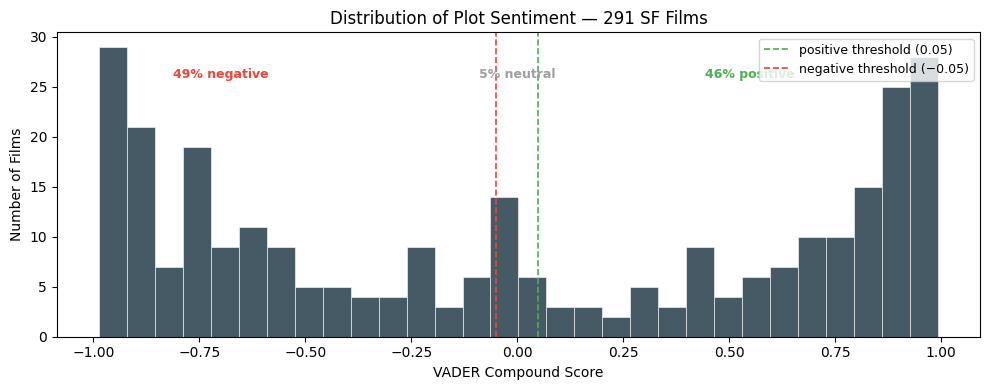

Overall: negative 49%  |  neutral 5%  |  positive 46%


In [ ]:
# Chart 1: Overall sentiment distribution
counts = df["sentiment_label"].value_counts()
total  = counts.sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["compound"].dropna(), bins=30, color="#455A64", edgecolor="white", linewidth=0.4)
ax.axvline( 0.05, color="#4CAF50", linestyle="--", linewidth=1.2, label="positive threshold (0.05)")
ax.axvline(-0.05, color="#F44336", linestyle="--", linewidth=1.2, label="negative threshold (−0.05)")
for label, color, x in [("negative","#F44336",-0.7),("neutral","#9E9E9E",0.0),("positive","#4CAF50",0.55)]:
    ax.text(x, ax.get_ylim()[1]*0.85,
            f"{counts.get(label,0)/total*100:.0f}% {label}",
            color=color, ha="center", fontsize=9, fontweight="bold")
ax.set_xlabel("VADER Compound Score")
ax.set_ylabel("Number of Films")
ax.set_title("Distribution of Plot Sentiment — 291 SF Films")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("Overall: negative {:.0f}%  |  neutral {:.0f}%  |  positive {:.0f}%".format(
    counts.get("negative",0)/total*100, counts.get("neutral",0)/total*100, counts.get("positive",0)/total*100))

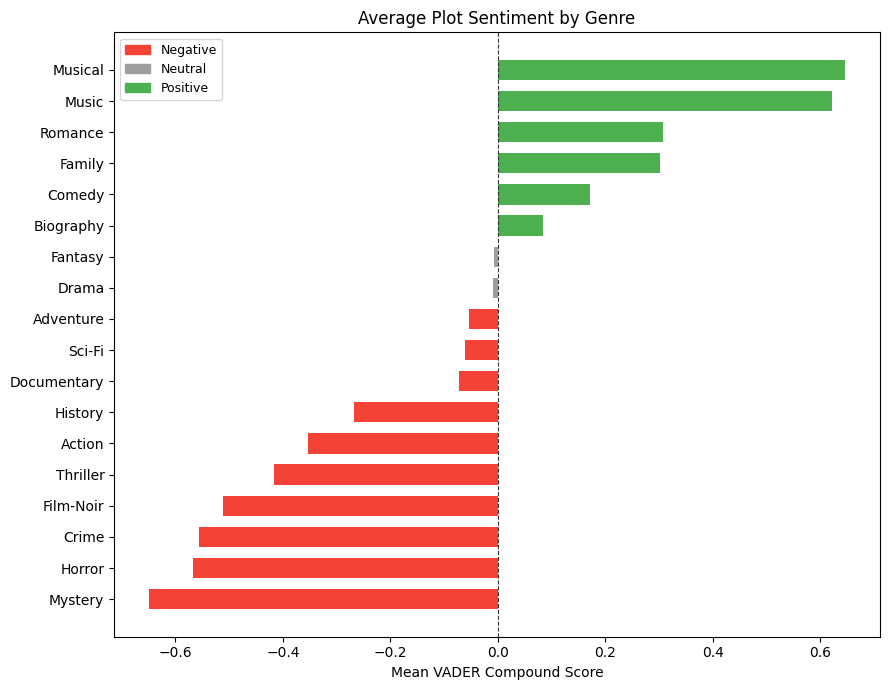

In [ ]:
# Chart 2: Average sentiment by genre
df_exploded = (
    df.dropna(subset=["compound","Genres"])
    .assign(genre=lambda d: d["Genres"].str.split(", "))
    .explode("genre")
    .assign(genre=lambda d: d["genre"].str.strip())
)
genre_stats = (
    df_exploded.groupby("genre")["compound"]
    .agg(mean="mean", count="count")
    .query("count >= 5")
    .sort_values("mean")
    .reset_index()
)
colors = ["#F44336" if m < -0.05 else "#9E9E9E" if m < 0.05 else "#4CAF50"
          for m in genre_stats["mean"]]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(genre_stats["genre"], genre_stats["mean"], color=colors, height=0.65)
ax.axvline(0, color="#333", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean VADER Compound Score")
ax.set_title("Average Plot Sentiment by Genre")
patches = [mpatches.Patch(color=c, label=l) for c, l in
           [("#F44336","Negative"),("#9E9E9E","Neutral"),("#4CAF50","Positive")]]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.show()

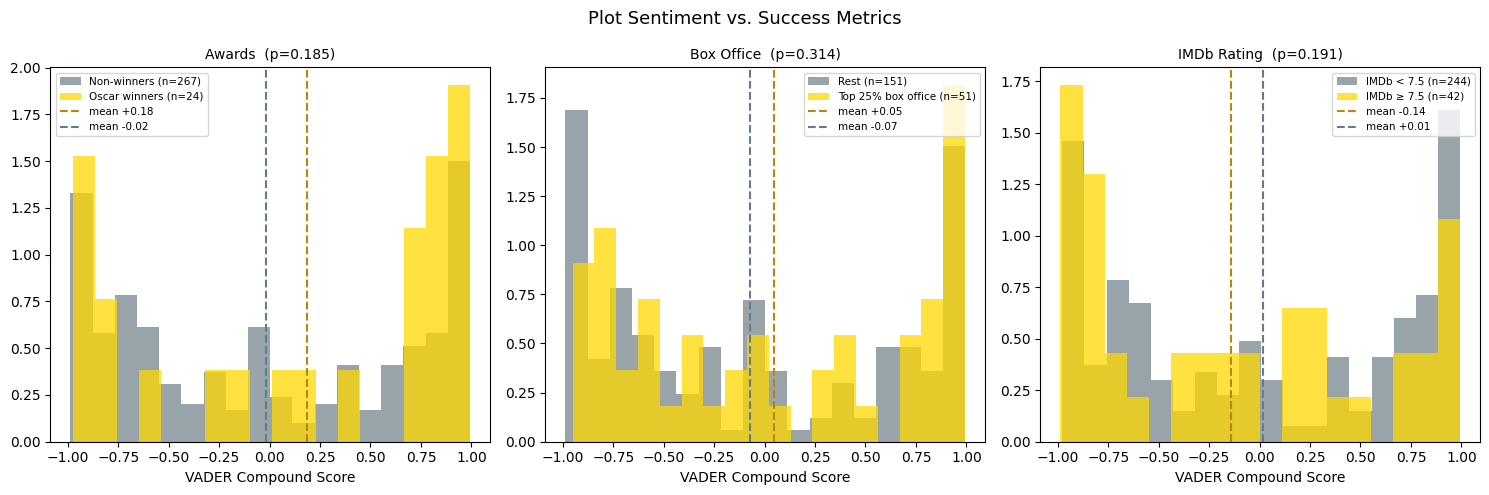

In [ ]:
# Chart 3: Sentiment vs. success metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Plot Sentiment vs. Success Metrics", fontsize=13)

bo_thresh   = df["box_office_num"].quantile(0.75)
comparisons = [
    ("Oscar winners",    df[df["won_oscar"]]["compound"].dropna(),
     "Non-winners",      df[~df["won_oscar"]]["compound"].dropna(),     axes[0], "Awards"),
    ("Top 25% box office", df[df["box_office_num"] >= bo_thresh]["compound"].dropna(),
     "Rest",               df[df["box_office_num"] <  bo_thresh]["compound"].dropna(), axes[1], "Box Office"),
    ("IMDb ≥ 7.5",      df[df["Imdb_rating"] >= 7.5]["compound"].dropna(),
     "IMDb < 7.5",      df[df["Imdb_rating"] <  7.5]["compound"].dropna(),            axes[2], "IMDb Rating"),
]
for label_a, grp_a, label_b, grp_b, ax, title in comparisons:
    ax.hist(grp_b, bins=18, density=True, alpha=0.55, color="#455A64", label=f"{label_b} (n={len(grp_b)})")
    ax.hist(grp_a, bins=18, density=True, alpha=0.75, color="#FFD700", label=f"{label_a} (n={len(grp_a)})")
    ax.axvline(grp_a.mean(), color="#B8860B", linestyle="--", linewidth=1.5,
               label=f"mean {grp_a.mean():+.2f}")
    ax.axvline(grp_b.mean(), color="#607D8B", linestyle="--", linewidth=1.5,
               label=f"mean {grp_b.mean():+.2f}")
    _, p = stats.ttest_ind(grp_a, grp_b)
    ax.set_title(f"{title}  (p={p:.3f})", fontsize=10)
    ax.set_xlabel("VADER Compound Score")
    ax.legend(fontsize=7.5)
plt.tight_layout()
plt.show()

#### Presentation on the website

The analysis produced three insights. The challenge was communicating them to a non-technical reader without introducing statistical jargon. We made three presentation decisions:

**1. The tone slider** (`toneScrolly`) — rather than opening with a histogram, the website shows a single film on a dark-to-uplifting scale. The reader first encounters *Zodiac* at −0.77 (dark), then scrolls to *Dr. Dolittle 2* at +0.43 (uplifting), then to *Babies* near zero (neutral). Only after those three concrete examples does the story move to aggregate patterns. The concrete-before-abstract ordering is what makes the compound score feel intuitive — the reader has already calibrated what −0.77 and +0.43 feel like before being shown a chart full of numbers.

**2. The genre sentiment chart** (`genreFrame`) — the bar chart presents genre-level average sentiment as a horizontal bar chart. The horizontal form was chosen because genre labels are long and horizontal bars are easier to scan for rank than vertical columns. Ordering by score (not alphabetically) makes the emotional spectrum immediately visible — Documentary and Biography cluster at the positive end, Horror at the negative.

**3. The sentiment vs. success histograms** (`sentimentFrame`) — overlapping histograms compare dark vs. uplifting films across three success dimensions: Oscar recognition, box office performance, and IMDb rating. The histogram format was chosen because showing two full distributions is more honest than comparing two means — the groups overlap substantially, and showing only means would overstate the effect. The three comparisons were sequenced to build a narrative: tone matters most for critical recognition (Oscars), less for commercial success (box office), and audiences are the most drawn to darker material (IMDb).


In [ ]:
from IPython.display import IFrame, display

# Genre sentiment bar chart — average VADER compound score per genre
# Source: genreFrame in website_possible_final_2.html
display(IFrame('genre_sentiment_chart.html', width='100%', height=420))


In [ ]:
from IPython.display import IFrame, display

# Sentiment vs. success histograms — dark vs. uplifting across Oscar / box office / IMDb
# Source: sentimentFrame in website_possible_final_2.html
display(IFrame('sentiment_histograms.html', width='100%', height=480))


### 'Now It's Your Turn!' — Final Interactive Map

The website closes by handing control to the reader. A full interactive Leaflet map lets anyone click on any filming location to see the film's title, IMDb rating, box office revenue, and Oscar status in a popup. This is the open-ended exploration phase of the Martini Glass structure — after being guided through the story, the reader is invited to test their own hypotheses.


#### Analysis

For this last section, most of the previous visualizations analysis was reused. It was a combination of most of the things that have already been showed. However, a simple version of it is showed here (without HTML styling) to give a sense of how was it constructed.


In [14]:
# Load
import pandas as pd
import folium
from folium.plugins import MarkerCluster
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [ ]:
# Load and prepare
df = pd.read_csv("sf_movies_cleaned.csv")

# Drop rows without coordinates and create a primary genre column for coloring the markers
df_map = df.dropna(subset=["Latitude", "Longitude"]).copy()
df_map["Primary_Genre"] = (
    df_map["Genres"].fillna("Other").str.split(",").str[0].str.strip()
)

# Define colors for genres
GENRE_COLORS = {
    "Drama":        "#4A90D9",
    "Thriller":     "#E05C3A",
    "Crime":        "#8B6FD4",
    "Comedy":       "#2DBD8F",
    "Action":       "#E8A030",
    "Romance":      "#D45C8A",
    "Documentary":  "#6BAD2A",
    "Horror":       "#6B5FD4",
    "Sci-Fi":       "#9B9B9B",
    "Biography":    "#2DBD8F",
    "Mystery":      "#8B6FD4",
    "Other":        "#666660",
}

# Assign the colors based on primary genre
def get_color(genre):
    for key in GENRE_COLORS:
        if key.lower() in str(genre).lower():
            return GENRE_COLORS[key]
    return GENRE_COLORS["Other"]

# Get sentiment scores (in this simplified example, it is not showed)
analyzer = SentimentIntensityAnalyzer()

# Function to compute compound score for a given plot summary
def score_plot(text):
    if pd.isna(text) or str(text).strip() == "":
        return None
    scores = analyzer.polarity_scores(str(text))
    return round(scores["compound"], 4)

df_map["compound"] = df_map["Plot"].apply(score_plot)

# Information about sentiment coverage
print(f"Sentiment computed: {df_map['compound'].notna().sum()} films with scores, "
      f"{df_map['compound'].isna().sum()} without plot data")

# Build records
records = []

# Loop through each row and build a record with cleaned and parsed data
for _, row in df_map.iterrows():
    all_genres = [g.strip() for g in str(row.get("Genres") or "Other").split(",") if g.strip()]
    if not all_genres:
        all_genres = ["Other"]

    year_val   = row.get("Year")
    year       = int(year_val) if pd.notna(year_val) else None
    decade     = (year // 10 * 10) if year is not None else None

    rating_val = row.get("Imdb_rating")
    rating     = float(rating_val) if pd.notna(rating_val) else None

    box_val = None
    raw_box = str(row.get("Box_office") or "").strip()
    if raw_box and raw_box not in ("N/A", "nan"):
        try:
            box_val = int(raw_box.replace("$", "").replace(",", "").strip())
        except ValueError:
            pass

    compound_val = None
    raw_compound = row.get("compound")
    if pd.notna(raw_compound):
        try:
            compound_val = round(float(raw_compound), 4)
        except (ValueError, TypeError):
            pass

    records.append({
        "genres":   all_genres,
        "decade":   decade,
        "rating":   rating,
        "box":      box_val,
        "compound": compound_val,
        "has_plot": compound_val is not None,
        "lat":      float(row["Latitude"]),
        "lng":      float(row["Longitude"]),
        "title":    str(row.get("Title", "")),
        "year":     year,
        "location": str(row.get("Locations", "") or ""),
    })

# Print some summary stats about the possible information showed when clicking on a marker in the interactive map
records_df = pd.DataFrame(records)
print(f"\nRecords built: {len(records_df):,}")
print(f"Decade range:  {records_df['decade'].min()}s → {records_df['decade'].max()}s")
print(f"Rating range:  {records_df['rating'].min():.1f} – {records_df['rating'].max():.1f}")
print(f"With plot:     {records_df['has_plot'].sum():,} / {len(records_df):,}")
print(f"\nTop genres:\n{records_df['genres'].explode().value_counts().head(8).to_string()}")

# Create map with clustered markers colored by primary genre
map_inter = folium.Map(
    location=[37.7749, -122.4194],
    zoom_start=12,
    tiles="CartoDB dark_matter",
)

# Make clusters according to the map zoom level
cluster = MarkerCluster(
    maxClusterRadius=50,
    disableClusteringAtZoom=15,
).add_to(map_inter)

# Add markers for each filming location
for rec in records:
    folium.CircleMarker(
        location=[rec["lat"], rec["lng"]],
        radius=6,
        color="white",
        weight=1,
        fill=True,
        fill_color=get_color(rec["genres"][0]),
        fill_opacity=0.85,
        tooltip=f"{rec['title']} ({rec['year']}) — {rec['genres'][0]}",
    ).add_to(cluster)

#map_inter.save("sf_map_interactive.html")
#print("Saved — open sf_map_interactive.html to view the map")
map_inter

Sentiment computed: 2156 films with scores, 0 without plot data

Records built: 2,156
Decade range:  1910s → 2020s
Rating range:  3.8 – 8.8
With plot:     2,156 / 2,156

Top genres:
genres
Drama       1384
Comedy       761
Mystery      513
Romance      506
Crime        458
Thriller     423
Action       388
Sci-Fi       296


#### Presentation on the website

Placing a free-exploration map at the end — after the guided narrative — is the defining feature of the Martini Glass structure (Segel & Heer, 2010). The reader arrives at this map having already been shown *what patterns exist* (where films concentrate, how sentiment correlates with success). The map gives them the tools to test those patterns themselves: does the high-box-office cluster really sit in Lone Mountain? Are the Oscar-winning films really where the heat map said they were?

The click-to-reveal popup format was chosen over always-on labels because a map of 316 clickable points would be unreadable if all labels were visible at once. Click-to-reveal rewards exploration without front-loading information — consistent with the 'reader as explorer' framing of this final section.


## Discussion

Reflecting on the project, bringing this data to life provided valuable insights into both the technical and narrative elements of data visualization. 

### What went well?
* **Data Integration:** Integrating geographic information from the San Francisco Open Data portal with the OMDb API was seamless. This approach bridged the gap between basic location data and richer cinematic metrics, such as box office numbers, awards, and IMDb ratings. This gave us a more comprehensive dataset to work with.
* **Scrollytelling Execution:** The Martini Glass narrative structure was highly effective. Beginning with an author-driven, scrollytelling map engaged the user without overwhelming them. This approach paced the introduction of complex variables (geography, time, and success metrics) before transitioning to full interactive control at the conclusion.
* **The Cinematic Aesthetic:** The visual design featuring dark modes, gold accents, and smooth map transitions, effectively captured the movie theme and created an immersive user experience.

### What is still missing?
* **Deeper Qualitative Data:** While our matching process was successful, our analysis relies on the high-level metrics provided by the OMDb API, such as overall ratings and short plot summaries. Having access to deeper, user-generated data (like full text reviews from IMDb) would have allowed for a much more nuanced and accurate sentiment analysis of how audiences actually felt about these films.
* **Granular Sentiment Context:** Although we applied sentiment analysis to movie plots, film emotions are highly subjective. Depending solely on text summaries may overlook nuanced tones present in the actual films, such as comedies with dark or violent premises.

### What could be improved? Why?
* **Mobile Responsiveness:** The current interactive maps and scrollytelling elements are optimized for desktop viewing. Enhancing the mobile layout would make the story accessible to a broader audience, as complex map visualizations can be challenging to navigate on smaller screens.
* **More Interactivity in Early Stages:** While the Martini Glass structure effectively guides the user, adding interactive elements, such as hovering over a decade to reveal the top film during the introduction, could further engage users before the final exploration stage.
* **Expanded Definition of Success:** We defined "success" using box office performance, Oscars, and IMDb ratings. Incorporating a metric such as "Return on Investment" (budget versus box office) could provide a more accurate perspective on commercial success, as high box office gross does not always indicate high profitability.

## Contributions

We have started by brainstorming together and setting up the structure of the website.
Then we have split the analysis in the following way:
* Introduction - Hinojosa, Omar González (s) & Babeii, Denisa (s253528)
* 'San Francisco on screen' - Hinojosa, Omar González (s)
* Maps section - Babeii, Denisa (s253528)
* 'Looking beyond location' - Ilves, Ursula (s) - analysis, Hinojosa, Omar González (s) - infographics & text, Babeii, Denisa (s253528) - text
* 'What does this tell us?' - Hinojosa, Omar González (s) & Babeii, Denisa (s253528)
* 'Now it's your turn!' - Hinojosa, Omar González (s)
* Notebook parts 1-3 - Hinojosa, Omar González (s)
* Notebook part 4 - Babeii, Denisa (s253528)
* Notebook part 5 - Ilves, Ursula (s), Hinojosa, Omar González (s), Babeii, Denisa (s253528)
* Notebook part 6 - Ilves, Ursula (s)

## References

<div id="references">
  <p style="font-weight:600;">Sites</p>
  <p id="ref1">[1] San Francisco Open Data Portal. (2026). Film Locations in San Francisco. Retrieved from <a href="https://data.sfgov.org/Culture-and-Recreation/Film-Locations-in-San-Francisco/yitu-d5am/about_data" target="_blank">https://data.sfgov.org/Culture-and-Recreation/Film-Locations-in-San-Francisco/yitu-d5am/about_data</a></p>
  <p id="ref2">[2] Open Movie Database (OMDb) API. (2026). Retrieved from <a href="https://www.omdbapi.com/" target="_blank">https://www.omdbapi.com/</a></p>
  <p id="ref3">[3] San Francisco Open Data Portal. (2026). SF Find Neighborhoods. Retrieved from <a href="https://data.sfgov.org/-/SF-Find-Neighborhoods/pty2-tcw4" target="_blank">https://data.sfgov.org/-/SF-Find-Neighborhoods/pty2-tcw4</a></p>
</div>

## Appendix

### Creating the complete San Francisco dataset

In [ ]:
# Libraries to use

from dotenv import load_dotenv
import os
import requests
import time
import json
import pandas as pd

#### Film Location database (OpenSF)
- It originally contains 2214 rows and 18 columns
- There are 350 unique titles

In [ ]:
# Read the csv file and show the columns and the first rows to quickly explore the data
df = pd.read_csv("data/Film_Locations_in_San_Francisco_20260414.csv")

# Remove the columns that are not needed for the analysis
df = df.drop(columns=["Point", "Supervisor District", "data_as_of", "data_loaded_at"])

# Remove leading and trailing spaces from the Title column
df["Title"] = df["Title"].str.strip()

The following little code was used to save the unique titles in a csv file
- The Release Year was included to ensure the correct title was retrieved
- With that file, all the 350 unique titles were manually searched to mark them in case they had a different name in IMDb (OMDb)
- If they had a different name or were specific episodes of a series, the IMDb ID was added to them (manual)
- If they were not found in IMDb, they were flagged as "delete"

In [ ]:
# Save the unique titles with their year in a csv file

# df_unique_titles = df[["Title", "Release Year"]].drop_duplicates()
# df_unique_titles.to_csv("unique_titles.csv", index=False)

- Quick Note: "Nash Bridges" and "Super Pumped: The Battle for Uber" have two different Release Years as they are series

#### Adapting the unique titles with the IMDB data and format

In [ ]:
# Load the IMDB specifications file which was manually made
df_imdb = pd.read_csv("data/unique_titles.csv")

# Merge IMDB specifications into the original dataset
df = df.merge(
    df_imdb[["Title", "IMDB specification"]],   # only bring Title + IMDB columns
    on="Title",
    how="left"                           # keep all rows from original dataset
)

# Fill any titles not in the specs file with empty string
df["IMDB specification"] = df["IMDB specification"].fillna("")

Verification of the merging and information about it

In [ ]:
# Count empty IMDb IDs
empty_count    = (df["IMDB specification"].str.strip() == "").sum()
# Count the "delete" specifications
delete_count   = (df["IMDB specification"].str.strip().str.lower() == "delete").sum()
# Count the valid IMDb IDs (all start with "tt")
tt_count       = df["IMDB specification"].str.strip().str.startswith("tt").sum()

# Catch anything unexpected in the IMDB column
unexpected     = df[
    ~(df["IMDB specification"].str.strip() == "") &
    ~(df["IMDB specification"].str.strip().str.lower() == "delete") &
    ~(df["IMDB specification"].str.strip().str.startswith("tt"))
]["IMDB specification"].unique()

print(f"Search by title:         {empty_count}")
print(f"To delete:               {delete_count}")
print(f"IMDb ID (tt...):         {tt_count}")
print(f"Unexpected values:       {unexpected}")

- 16 rows (values) were deleted as they were not in the IMDB base or were only one episode of series which location was not in San Francisco (Ex. CSI: NY - episode 903)
- Those 16 rows corresponded to 7 Unique Titles
- 1224 rows are going to be searched by the manually written IMDB ID, that is for 156 Unique Titles
- 1020 rows are going to be searched by the Title (which needs an exact match), that is for 189 Unique Titles

#### Retrieve the data from the OMDb API

In [ ]:
# Get an API Key in the following site: https://www.omdbapi.com/apikey.aspx
load_dotenv()
OMDB_API_KEY = os.getenv("OMDB_API_KEY")    # Use of env for security reasons

In [ ]:
def fetch_movie_by_id(imdb_id):
    """Fetch movie data from OMDB API by IMDb ID"""
    url = "http://www.omdbapi.com/"
    params = {
        "i":      imdb_id.strip(),
        "apikey": OMDB_API_KEY,
        "plot":   "full"
    }
    response = requests.get(url, params=params, timeout=10)
    return response.json()

def fetch_movie_by_title(title):
    """Fetch movie data from OMDB API by title"""
    url = "http://www.omdbapi.com/"
    params = {
        "t":      title.strip(),
        "apikey": OMDB_API_KEY,
        "plot":   "full"
    }
    response = requests.get(url, params=params, timeout=10)
    return response.json()



# First, remove all rows where the IMDb ID is "delete"
titles_to_delete = df[df["IMDB specification"].str.strip().str.lower() == "delete"]["Title"].unique()

# Remove rows with "delete" specification
if len(titles_to_delete) > 0:
    df = df[~df["Title"].isin(titles_to_delete)].reset_index(drop=True)

print(f"Rows after deletions: {len(df)}")



# Second, build a unique title + IMDb ID lookup
df_unique = (df[["Title", "IMDB specification"]]
             .drop_duplicates(subset=["Title"])
             .reset_index(drop=True))

# There should be 343, as 350 originally minus 7 deleted titles
print(f"Unique titles to fetch: {len(df_unique)}")



# Third, fetch the data
data = []
failed = []

# Iterate over unique titles and their IMDb specifications
for _, row in df_unique.iterrows():
    title = str(row["Title"]).strip()
    imdb_spec = str(row["IMDB specification"]).strip() if pd.notna(row["IMDB specification"]) else ""

    try:
        # Rule: IMDb ID provided → search by ID first
        if imdb_spec.lower().startswith("tt"):
            result = fetch_movie_by_id(imdb_spec)
            search_method = "imdb_id"

        # Rule: Empty spec → search by title
        elif imdb_spec == "" or imdb_spec.lower() == "nan":
            result = fetch_movie_by_title(title)
            search_method = "title"

        # If there is an unexpected value → log and skip
        else:
            failed.append(title)
            continue

        # OMDb returns {"Response": "False"} when nothing is found
        if result.get("Response") == "False":
            failed.append(title)
            continue

        data.append({
            # search metadata
            "title_searched":       title,

            # identity
            "imdb_id":              result.get("imdbID"),
            "title":                result.get("Title"),
            "year":                 result.get("Year"),
            "kind":                 result.get("Type"),

            # content
            "genres":               result.get("Genre"),
            "plot":                 result.get("Plot"),
            "language":             result.get("Language"),
            "country":              result.get("Country"),
            "certificates":         result.get("Rated"),
            "runtime":              result.get("Runtime"),
            "awards":               result.get("Awards"),

            # people
            "directors":            result.get("Director"),
            "writers":              result.get("Writer"),

            # ratings
            "imdb_rating":          result.get("imdbRating"),
            "imdb_votes":           result.get("imdbVotes"),
            "metascore":            result.get("Metascore"),
            "ratings":              result.get("Ratings"),

            # commercial
            "box_office":           result.get("BoxOffice"),

            # media
            "poster":               result.get("Poster"),
        })

    # for errors
    except Exception as e:
        failed.append(title)

    # to avoid rate limits
    finally:
        time.sleep(0.3)

#### Saving the json of the fetched data

In [ ]:
temp_path  = "data/omdb_data_temp.json"
final_path = "data/omdb_data.json"

if data:
    # Write to temp file first
    with open(temp_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    
    # Only replace original once temp is fully written
    os.replace(temp_path, final_path)
    print(f"Saved {len(data):,} records to {final_path}")
else:
    print("Nothing saved")

# Summary
print(f"Fetched:  {len(data):,}")
print(f"Failed:   {len(failed):,}")

#### Join the fetched data with the original SF dataset

In [ ]:
# Load the OMDb json file 
with open("data/omdb_data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df_imdb = pd.DataFrame(data)

# Replace "N/A" strings with actual NaN
df_imdb = df_imdb.replace("N/A", pd.NA)

# Convert numeric columns
df_imdb["imdb_rating"] = pd.to_numeric(
    df_imdb["imdb_rating"], errors="coerce"
)
df_imdb["imdb_votes"] = (
    df_imdb["imdb_votes"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)

# Ensure numeric year in common format (4-digit year)
df_imdb["year"] = pd.to_numeric(
    df_imdb["year"].astype(str).str.extract(r'(\d{4})')[0],
    errors="coerce"
)

# Flatten nested ratings column
def extract_rating(ratings_list, source):
    if not isinstance(ratings_list, list):
        return pd.NA
    for r in ratings_list:
        if r.get("Source") == source:
            return r.get("Value")
    return pd.NA

df_imdb["rt_score"]         = df_imdb["ratings"].apply(
    lambda x: extract_rating(x, "Rotten Tomatoes"))
df_imdb["metacritic_score"] = df_imdb["ratings"].apply(
    lambda x: extract_rating(x, "Metacritic"))
df_imdb["imdb_score"]       = df_imdb["ratings"].apply(
    lambda x: extract_rating(x, "Internet Movie Database"))

df_imdb = df_imdb.drop(columns=["ratings"])

# Print basic info
print(f"Total records:         {len(df_imdb):,}")
print(f"Columns:               {len(df_imdb.columns)}")
print(f"Movies (kind=movie):   {(df_imdb['kind'] == 'movie').sum()}")
print(f"Series (kind=series):  {(df_imdb['kind'] == 'series').sum()}")

# Print info about missing values
print("\nMissing values per column:")
missing = df_imdb.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)



# Merge data with the original SF dataset
df_final = df.merge(
    df_imdb,
    left_on="Title",            # original CSV title column
    right_on="title_searched",  # OMDB searched title column
    how="left"                  # keep ALL location rows even if no OMDB match
)

# Check the merge
print(f"\nMerge Summary:")
print(f"Original SF rows:      {len(df):,}")
print(f"After merge rows:      {len(df_final):,}")
print(f"Matched rows:          {df_final['imdb_id'].notna().sum():,}")
print(f"Unmatched rows:        {df_final['imdb_id'].isna().sum():,}")
print(f"Total columns:         {len(df_final.columns)}")

# List the unmatched titles (should be 7, as per the "delete" specifications)
unmatched = df_final[df_final["imdb_id"].isna()]["Title"].unique()
if len(unmatched) > 0:
    print(f"\nUnmatched titles ({len(unmatched)}):")
    for t in sorted(unmatched):
        print(f"{t}")

Clean the combined dataset for the final result

In [ ]:
# Fill the empty "Writer" values of the original dataset with the "writers" from OMDB, if available
df_final["Writer"] = df_final["Writer"].fillna(df_final["writers"])

# Clean "runtime" column and convert to numeric minutes
def clean_runtime(value):
    if pd.isna(value):
        return pd.NA
    value = str(value).strip()
    value = value.lower().replace("min", "").strip()
    value = ''.join(c for c in value if c.isdigit() or c == '.')
    try:
        return float(value) if '.' in value else int(value)
    except ValueError:
        return pd.NA

df_final["runtime"] = df_final["runtime"].apply(clean_runtime)

# Drop the unnedded columns
columns_to_drop = [
    "Title",
    "Release Year",
    "directors",
    "writers",
    "title_searched",
    "IMDB specification",
    "imdb_score"
]

existing_to_drop = [c for c in columns_to_drop if c in df_final.columns]
missing_to_drop  = [c for c in columns_to_drop if c not in df_final.columns]

if missing_to_drop:
    print(f"\nColumns not found and skipped:")
    for c in missing_to_drop:
        print(f"{c}")

df_final = df_final.drop(columns=existing_to_drop)

# Check shape after dropping
print(f"Shape after dropping:   {df_final.shape}")


# Delete rows for unmatched titles
rows_to_remove = df_final[df_final["imdb_id"].isna()].shape[0]
df_final = df_final[df_final["imdb_id"].notna()].reset_index(drop=True)
print(f"Rows removed:          {rows_to_remove}")
print(f"Final shape:           {df_final.shape}")


# Capitalize all column names
df_final.columns = [col.capitalize() for col in df_final.columns]

# Fix specific column names after capitalizing
df_final = df_final.rename(columns={
    "Imdb_id":          "IMDB_id",
    "Imdb_rating":      "IMDB_rating",
    "Imdb_votes":       "IMDB_votes",
    "Rt_score":         "RT_score",
})



# Move Title column to the front
cols = ["Title"] + [col for col in df_final.columns if col != "Title"]
df_final = df_final[cols]



# Save cleaned dataset to a new CSV file
temp_path  = "data/sf_movies_cleaned_temp.csv"
final_path = "data/sf_movies_cleaned.csv"

df_final.to_csv(temp_path, index=False, encoding="utf-8")
os.replace(temp_path, final_path)

print(f"\nSaved cleaned dataset to '{final_path}'")
print(f"  Shape:     {df_final.shape}")
print(f"  File size: {os.path.getsize(final_path) / 1e6:.2f} MB")

#### Important notes
- The Box Office column is not included in all movies, and it also shows only the "Domestic" office, that is US and Canada as stated in [IMDb help site](https://help.imdb.com/article/imdbpro/industry-research/box-office-mojo-by-imdbpro-faq/GCWTV4MQKGWRAUAP#)
- There are 202 movies with Box Office information, while 114 do not have that information

### Exploratory Data Analysis

In [22]:
# Load the dataset
df = pd.read_csv("sf_movies_cleaned_og.csv")

In [24]:
print(f"  Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

unique_genres = (
    df["Genres"]
    .dropna()
    .str.split(", ")
    .explode()
    .str.strip()
    .unique()
)

print(f"Number of unique genres: {len(unique_genres)}")
print(sorted(unique_genres))

print(f"  Neighborhoods:    {df['Analysis neighborhood'].dropna().nunique()}")

  Dataset loaded: 2,244 rows × 30 columns
Number of unique genres: 24
['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War', 'Western']
  Neighborhoods:    40


In [26]:
# List of unique titles with box office data, IMDb reviews data, awards data for movies
df_movies = df[df["Kind"] == "movie"]
print(f"Total unique movie titles: {df_movies['Title'].nunique():,}")
box_office_titles = df_movies[df_movies["Box_office"].notna()]["Title"].unique()
imdb_titles = df_movies[df_movies["Imdb_rating"].notna()]["Title"].unique()
awards_titles = df_movies[df_movies["Awards"].notna()]["Title"].unique()
print(f"  Titles with box office data: {len(box_office_titles):,}")
print(f"  Titles with IMDb reviews:    {len(imdb_titles):,}")
print(f"  Titles with awards data:     {len(awards_titles):,}")

Total unique movie titles: 291
  Titles with box office data: 202
  Titles with IMDb reviews:    286
  Titles with awards data:     243


In [23]:
# Get number of unique titles with values for box office and number of does who have no box office
df_titles = df_map.drop_duplicates(subset=["Title"])

has_bo    = df_titles["Box_office"].notna().sum()
no_bo     = df_titles["Box_office"].isna().sum()

print(f"Titles with box office:    {has_bo}")
print(f"Titles without box office: {no_bo}")
print(f"Total unique titles:       {has_bo + no_bo}")

# Check if all Titles with box office are movies (not TV shows)
movies_with_bo = df_titles[df_titles["Box_office"].notna()]["Kind"].value_counts().get("movie", 0)
print(f"Movies with box office:    {movies_with_bo}")


Titles with box office:    165
Titles without box office: 98
Total unique titles:       263
Movies with box office:    165


Number of unique neighborhoods: 40


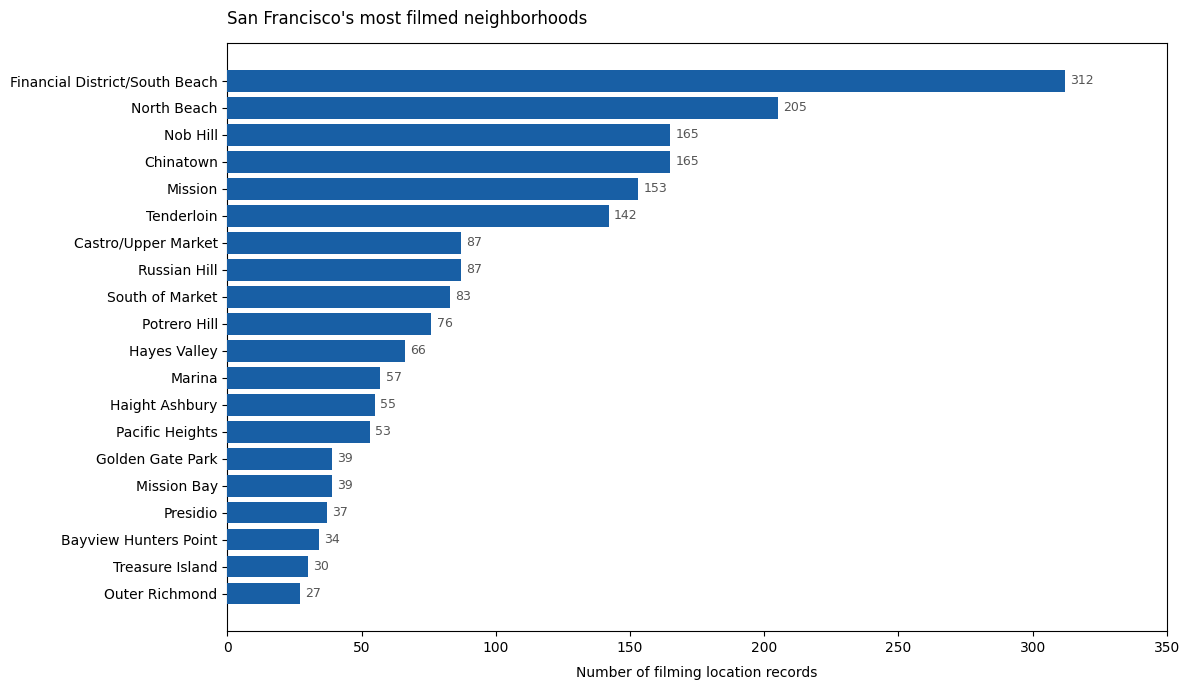

In [28]:
# Filming frequency in neighborhoods

# Get the number of unique neighborhoods
num_neighborhoods = df['Analysis neighborhood'].nunique()
print(f"Number of unique neighborhoods: {num_neighborhoods}")

fig, ax = plt.subplots(figsize=(12, 7))

# Aggregate
neighborhood_counts = (
    df.groupby("Analysis neighborhood")
    .size()
    .sort_values(ascending=True)
    .tail(20)                            
)

bars = ax.barh(
    neighborhood_counts.index,
    neighborhood_counts.values,
    color= "#185FA5",
    # no grid lines on the graph
    zorder = 3
)

# Value labels
for bar, val in zip(bars, neighborhood_counts.values):
    ax.text(
        bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center", ha="left",
        fontsize=9, color="#555"
    )

ax.set_xlabel("Number of filming location records", labelpad=8)
ax.set_title(
    "San Francisco's most filmed neighborhoods",
    pad=14, loc="left"
)

ax.set_xlim(0, 350)

fig.tight_layout()
plt.show()

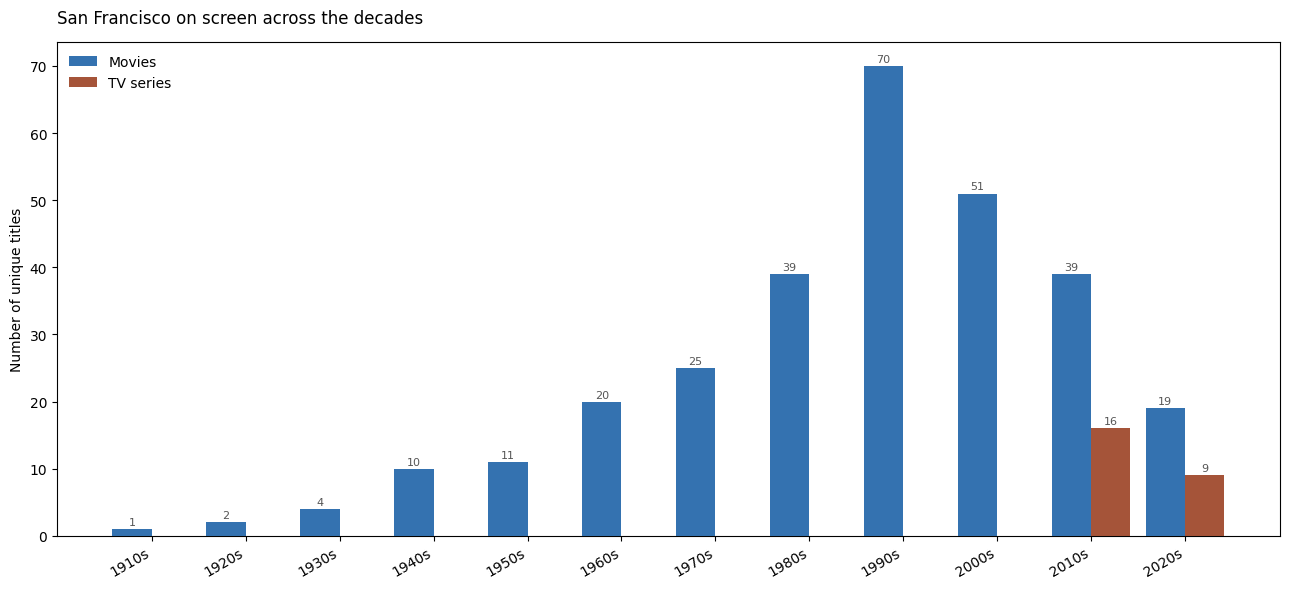

In [29]:
# San Francisco filming activity across decades

# Extract decade from Year
df["Decade"] = (df["Year"].dropna() // 10 * 10).astype("Int64")

# Count titles per decade per kind
decade_kind = (
    df.dropna(subset=["Decade"])
    .drop_duplicates(subset=["Title"])          # one row per title
    .groupby(["Decade", "Kind"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Keep decades from 1900 onwards
decade_kind = decade_kind[decade_kind.index >= 1900]

decades = decade_kind.index.astype(int).tolist()
movies  = decade_kind.get("movie",  pd.Series(0, index=decade_kind.index)).tolist()
series  = decade_kind.get("series", pd.Series(0, index=decade_kind.index)).tolist()

fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(decades))
w = 0.42

bars_m = ax.bar(x - w/2, movies, width=w,
                color="#185FA5", alpha=0.88, label="Movies", zorder=3)
bars_s = ax.bar(x + w/2, series, width=w,
                color="#993C1D", alpha=0.88, label="TV series", zorder=3)

# Value labels on bars
for bar in list(bars_m) + list(bars_s):
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.3,
            str(int(h)),
            ha="center", va="bottom",
            fontsize=8, color="#555"
        )

ax.set_xticks(x)
ax.set_xticklabels([f"{d}s" for d in decades], rotation=30, ha="right")
ax.set_ylabel("Number of unique titles")
ax.set_title(
    "San Francisco on screen across the decades",
    pad=14, loc="left"
)

legend = ax.legend(
    frameon=False,
    loc="upper left",
    fontsize=10
)

fig.tight_layout()
plt.show()

Rows before dedup: 1,022
Rows after dedup:  648
Unique titles:     157
Unique neighborhoods: 39
Unique decades:       9


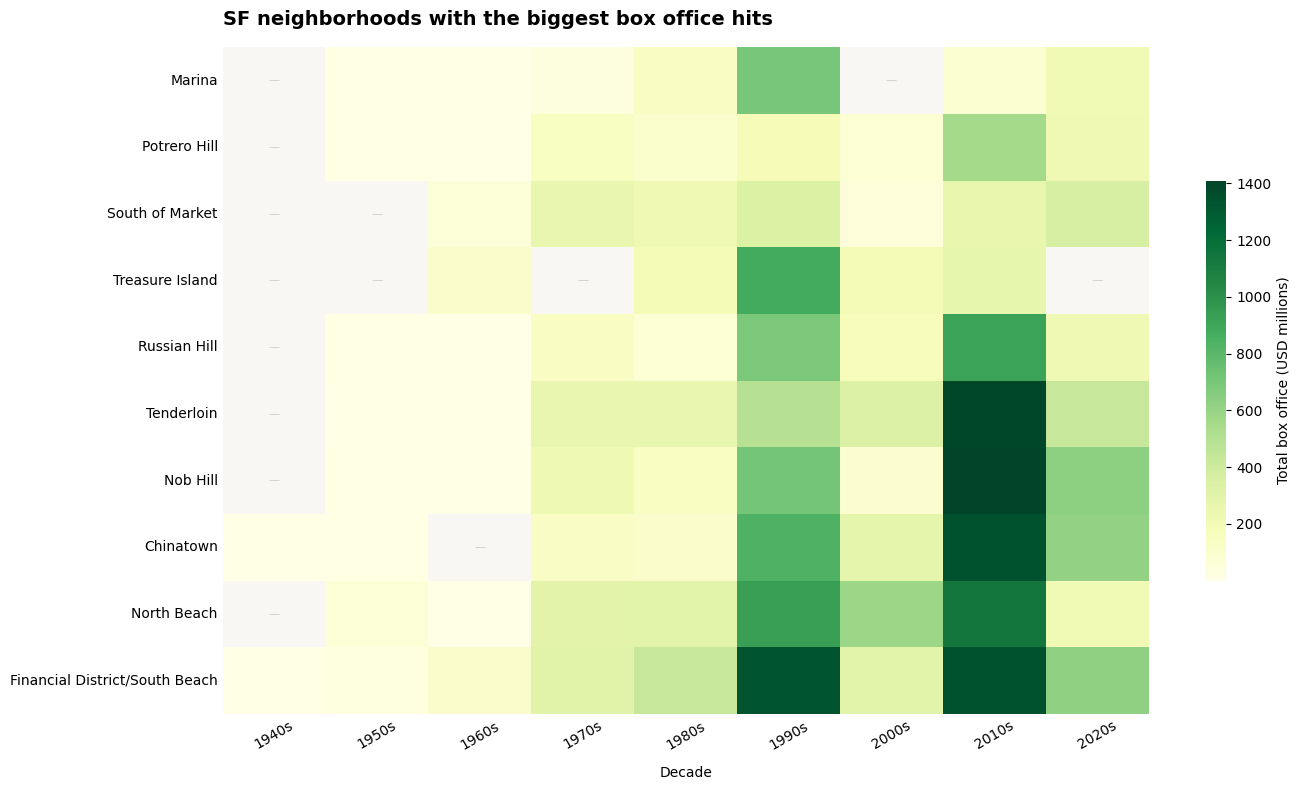

In [30]:
# Heatmap of neighborhood and decade (Box office)
import seaborn as sns

# Clean box office column
df_bo = df.copy()

df_bo["Box_office_clean"] = (
    df_bo["Box_office"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .str.strip()
    .pipe(pd.to_numeric, errors="coerce")
)

# Extract decade
df_bo["Decade"] = (df_bo["Year"].dropna() // 10 * 10).astype("Int64")

# Drop rows missing key fields for the heatmap
df_bo = df_bo.dropna(subset=[
    "Box_office_clean",
    "Decade",
    "Analysis neighborhood"
])

# Deduplicate to avoid overcounting titles filmed in multiple neighborhoods
df_bo_dedup = (
    df_bo
    .drop_duplicates(subset=["Title", "Analysis neighborhood"])
    .copy()
)

print(f"Rows before dedup: {len(df_bo):,}")
print(f"Rows after dedup:  {len(df_bo_dedup):,}")
print(f"Unique titles:     {df_bo_dedup['Title'].nunique()}")
print(f"Unique neighborhoods: {df_bo_dedup['Analysis neighborhood'].nunique()}")
print(f"Unique decades:       {df_bo_dedup['Decade'].nunique()}")

# Aggregate total box office by neighborhood and decade
heatmap_data = (
    df_bo_dedup
    .groupby(["Analysis neighborhood", "Decade"])["Box_office_clean"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

# Keep only neighborhoods with box office data
heatmap_data = heatmap_data[heatmap_data.sum(axis=1) > 0]

# Top 10 neighborhoods
top_neighborhoods = (
    heatmap_data.sum(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
)
heatmap_data = heatmap_data.loc[top_neighborhoods]

# Sort them
heatmap_data = heatmap_data.loc[
    heatmap_data.sum(axis=1).sort_values(ascending=True).index
]

# Convert to millions for readability
heatmap_millions = heatmap_data / 1_000_000

# Format decade columns as strings with "s" suffix
heatmap_millions.columns = [
    f"{int(c)}s" for c in heatmap_millions.columns
]

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    heatmap_millions,
    ax=ax,
    cmap="YlGn",
    annot=False,
    fmt=".0f",
    annot_kws={"size": 8, "color": "#333"},
    cbar_kws={
        "label":       "Total box office (USD millions)",
        "shrink":      0.6,
        "orientation": "vertical",
    },
    mask=heatmap_millions == 0,
    zorder = 3
)

# ── Style zero cells explicitly ───────────────────────────────
ax.set_facecolor("#F8F7F4")

# ── Annotate zero cells with a dash ──────────────────────────
for i in range(heatmap_millions.shape[0]):
    for j in range(heatmap_millions.shape[1]):
        if heatmap_millions.iloc[i, j] == 0:
            ax.text(
                j + 0.5, i + 0.5, "—",
                ha="center", va="center",
                fontsize=8, color="#CCCCCC"
            )

# ── Highlight the top cell ────────────────────────────────────
max_pos = (
    heatmap_millions.stack()
    .idxmax()
)
max_row = heatmap_millions.index.tolist().index(max_pos[0])
max_col = heatmap_millions.columns.tolist().index(max_pos[1])
max_val = heatmap_millions.loc[max_pos[0], max_pos[1]]

# ── Labels and titles ─────────────────────────────────────────
ax.set_xlabel("Decade", labelpad=10)
ax.set_ylabel("")
ax.set_title(
    "SF neighborhoods with the biggest box office hits",
    pad=16, loc="left", fontsize=14, fontweight="bold"
)

ax.tick_params(axis="x", rotation=30, length=0)
ax.tick_params(axis="y", rotation=0,  length=0)

fig.tight_layout()
plt.show()